# 05B — Transformer Sentiment Analysis

## Objective

This notebook applies a pretrained Transformer as the second sentiment method.

**Model:** `cardiffnlp/twitter-roberta-base-sentiment-latest`

It predicts:

- Negative
- Neutral
- Positive

The notebook uses `text_clean_basic`, compares the results with VADER when
available, tracks long-text truncation, creates a manual-validation sample, and
exports the final combined sentiment dataset.

> The original processed dataset and source-provided labels are never overwritten.


## 1. Installation

Run this once in the active environment:

```bash
pip install transformers torch accelerate
```

The first execution needs internet access to download the model.


In [1]:
from pathlib import Path
import ast
import json
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    import torch
    import transformers
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
except ImportError as exc:
    raise ImportError(
        "Install the required packages with: "
        "pip install transformers torch accelerate"
    ) from exc


def find_project_root(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError(
        "Project root not found. Run the notebook from the project root "
        "or the notebooks folder."
    )


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "sentiment"
FIGURE_DIR = PROJECT_ROOT / "figures" / "sentiment"
ANALYSIS_READY_PATH = PROJECT_ROOT / "data" / "processed" / "analysis_ready_posts.jsonl"
VADER_PATH = RESULTS_DIR / "vader_predictions.jsonl"
CHECKPOINT_PATH = RESULTS_DIR / "transformer_checkpoint.csv"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32 if DEVICE.type == "cuda" else 8

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Device:", DEVICE)
print("Batch size:", BATCH_SIZE)
print("Results folder:", RESULTS_DIR)


PyTorch: 2.13.0+cu130
Transformers: 5.14.1
Device: cpu
Batch size: 8
Results folder: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment


## 2. Load and validate the input

The notebook loads VADER predictions when they exist. Otherwise, it loads the
analysis-ready dataset and performs Transformer analysis without method
comparison.


In [2]:
if VADER_PATH.exists():
    INPUT_PATH = VADER_PATH
    print("Loading VADER predictions for comparison.")
elif ANALYSIS_READY_PATH.exists():
    INPUT_PATH = ANALYSIS_READY_PATH
    print("VADER predictions not found; loading analysis-ready data.")
else:
    raise FileNotFoundError("No usable input dataset was found.")

df = pd.read_json(INPUT_PATH, lines=True)

required = ["record_id", "platform", "text_clean_basic"]
missing = [column for column in required if column not in df.columns]
if missing:
    raise ValueError("Missing required columns: " + ", ".join(missing))

df["text_clean_basic"] = (
    df["text_clean_basic"].fillna("").astype(str).str.strip()
)

checks = {
    "records": len(df),
    "missing_ids": int(df["record_id"].isna().sum()),
    "duplicate_ids": int(df["record_id"].duplicated().sum()),
    "empty_texts": int(df["text_clean_basic"].eq("").sum()),
    "vader_available": "vader_label" in df.columns,
}

display(pd.Series(checks, name="value").rename_axis("check").reset_index())

if checks["missing_ids"] or checks["duplicate_ids"] or checks["empty_texts"]:
    raise ValueError("The input dataset failed validation.")


def ensure_list(value):
    if isinstance(value, list):
        return value
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except (TypeError, ValueError):
        pass
    if isinstance(value, str):
        value = value.strip()
        if not value or value.lower() in {"nan", "none", "null", "[]"}:
            return []
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            pass
        return [value]
    return [value]

for column in ["ai_tools", "research_themes"]:
    if column in df.columns:
        df[column] = df[column].map(ensure_list)

if "created_at_utc" in df.columns:
    df["created_at_utc"] = pd.to_datetime(
        df["created_at_utc"], errors="coerce", utc=True
    )
else:
    df["created_at_utc"] = pd.NaT

print("Input:", INPUT_PATH)
print("Shape:", df.shape)
display(df.head())


Loading VADER predictions for comparison.


,check,value
0,records,2666
1,missing_ids,0
2,duplicate_ids,0
3,empty_texts,0
4,vader_available,True


Input: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment/vader_predictions.jsonl
Shape: (2666, 53)


,record_id,source_id,source,platform,community,created_at_utc,date_known,is_recent_2025_plus,title_raw,body_raw,...,quotes_count,reblogs_count,relevant,is_ai_relevant,text_hash,vader_negative,vader_neutral,vader_positive,vader_compound,vader_label
0,huggingface_uit-sentiment-dataset-reddit-2000-...,1kby1en,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-01 02:22:03+00:00,True,True,,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...,...,NaN,NaN,NaN,True,1d9ae9c76d041d305769df63eab8285c1388bd41ddb381...,0.00,0.918,0.082,0.3400,Positive
1,huggingface_uit-sentiment-dataset-reddit-2000-...,1kbym1e,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,OpenAI,2025-05-01 02:52:48+00:00,True,True,,current llms still suck I am using the top mod...,...,NaN,NaN,NaN,True,29a4834457d0d17c5a1c242f7e37fef03445e3bf3d6e70...,0.14,0.777,0.083,-0.6597,Negative
2,huggingface_uit-sentiment-dataset-reddit-2000-...,1kchgyo,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-01 19:33:44+00:00,True,True,,Anthropic claims chips are smuggled as prosthe...,...,NaN,NaN,NaN,True,9e6603632ea5d670404a9ecd536533f03bf059a3eee592...,0.04,0.872,0.088,0.4767,Positive
3,huggingface_uit-sentiment-dataset-reddit-2000-...,1kd9kcf,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,singularity,2025-05-02 19:28:21+00:00,True,True,,"I don't know why but being called a ""Human"" by...",...,NaN,NaN,NaN,True,60aae8494f66a3f27106f6ec44345e33c16342fd2e2208...,0.00,0.850,0.150,0.3919,Positive
4,huggingface_uit-sentiment-dataset-reddit-2000-...,1kdqcjk,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-03 11:00:49+00:00,True,True,,Teaching LLMs to use tools with RL! Successful...,...,NaN,NaN,NaN,True,3b7bb80042691fdd0933eba2ebad82d30ddc6c5ba2b2c0...,0.01,0.840,0.150,0.9858,Positive


## 3. Load the model

The model has three sentiment classes. The code verifies and normalizes the
label mapping before inference.


In [3]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
MAX_LENGTH = 512

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Loading model...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(DEVICE)
model.eval()


def normalize_label(label):
    mapping = {
        "label_0": "Negative",
        "label_1": "Neutral",
        "label_2": "Positive",
        "negative": "Negative",
        "neutral": "Neutral",
        "positive": "Positive",
    }
    key = str(label).strip().lower()
    if key not in mapping:
        raise ValueError(f"Unexpected model label: {label}")
    return mapping[key]

ID_TO_LABEL = {
    int(index): normalize_label(label)
    for index, label in model.config.id2label.items()
}

if set(ID_TO_LABEL.values()) != {"Negative", "Neutral", "Positive"}:
    raise ValueError("The selected model does not have the expected labels.")

print("Model:", MODEL_NAME)
print("Labels:", ID_TO_LABEL)
print("Maximum input length used:", MAX_LENGTH)


Loading tokenizer...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: cardiffnlp/twitter-roberta-base-sentiment-latest
Labels: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
Maximum input length used: 512


model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

## 4. Test the model on three simple sentences

In [4]:
examples = [
    "GitHub Copilot saves me a lot of time.",
    "The generated code keeps failing and it is frustrating.",
    "I tested ChatGPT today.",
]

encoded = tokenizer(
    examples,
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt",
)
encoded = {key: value.to(DEVICE) for key, value in encoded.items()}

with torch.inference_mode():
    probabilities = torch.softmax(model(**encoded).logits, dim=-1).cpu().numpy()

for text, probs in zip(examples, probabilities):
    predicted_id = int(probs.argmax())
    print(text)
    print("Prediction:", ID_TO_LABEL[predicted_id])
    print({ID_TO_LABEL[i]: round(float(p), 4) for i, p in enumerate(probs)})
    print()


GitHub Copilot saves me a lot of time.
Prediction: Positive
{'Negative': 0.013, 'Neutral': 0.1167, 'Positive': 0.8703}

The generated code keeps failing and it is frustrating.
Prediction: Negative
{'Negative': 0.9275, 'Neutral': 0.0643, 'Positive': 0.0082}

I tested ChatGPT today.
Prediction: Neutral
{'Negative': 0.0144, 'Neutral': 0.8981, 'Positive': 0.0875}



## 5. Measure token lengths and truncation

Transformer inputs are limited to 512 tokens. Longer records are analyzed using
the first 512 tokens. The notebook records how many texts were truncated.


In [5]:
texts = df["text_clean_basic"].tolist()
token_lengths = []

for start in range(0, len(texts), 128):
    batch = texts[start:start + 128]
    encoded_lengths = tokenizer(
        batch,
        add_special_tokens=True,
        truncation=False,
        padding=False,
        return_length=True,
    )["length"]
    if isinstance(encoded_lengths, int):
        encoded_lengths = [encoded_lengths]
    token_lengths.extend(int(length) for length in encoded_lengths)

df["transformer_token_count"] = token_lengths
df["transformer_was_truncated"] = df["transformer_token_count"] > MAX_LENGTH

truncation_summary = pd.DataFrame({
    "metric": [
        "records",
        "maximum_allowed_tokens",
        "records_exceeding_limit",
        "percentage_exceeding_limit",
        "median_token_count",
        "maximum_token_count",
    ],
    "value": [
        len(df),
        MAX_LENGTH,
        int(df["transformer_was_truncated"].sum()),
        round(df["transformer_was_truncated"].mean() * 100, 2),
        round(df["transformer_token_count"].median(), 2),
        int(df["transformer_token_count"].max()),
    ],
})

display(truncation_summary)
truncation_summary.to_csv(
    RESULTS_DIR / "transformer_truncation_summary.csv", index=False
)


,metric,value
0,records,2666.00
1,maximum_allowed_tokens,512.00
2,records_exceeding_limit,371.00
3,percentage_exceeding_limit,13.92
4,median_token_count,133.00
5,maximum_token_count,9258.00


## 6. Run batched Transformer inference

This is the longest cell. Progress is printed every ten batches, and a CSV
checkpoint is saved periodically.


In [6]:
all_probabilities = []
total_batches = int(np.ceil(len(texts) / BATCH_SIZE))
start_time = time.time()

for batch_number, start in enumerate(range(0, len(texts), BATCH_SIZE), start=1):
    batch_texts = texts[start:start + BATCH_SIZE]
    encoded = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    encoded = {key: value.to(DEVICE) for key, value in encoded.items()}

    with torch.inference_mode():
        batch_probs = torch.softmax(model(**encoded).logits, dim=-1).cpu().numpy()

    all_probabilities.extend(batch_probs.tolist())

    if batch_number == 1 or batch_number % 10 == 0 or batch_number == total_batches:
        elapsed = (time.time() - start_time) / 60
        print(
            f"Batch {batch_number}/{total_batches} | "
            f"Records {len(all_probabilities)}/{len(texts)} | "
            f"Elapsed {elapsed:.2f} min"
        )

    if batch_number % 20 == 0 or batch_number == total_batches:
        checkpoint = np.asarray(all_probabilities, dtype=float)
        pd.DataFrame({
            "record_id": df.loc[:len(checkpoint)-1, "record_id"].values,
            "probability_0": checkpoint[:, 0],
            "probability_1": checkpoint[:, 1],
            "probability_2": checkpoint[:, 2],
        }).to_csv(CHECKPOINT_PATH, index=False)

print(f"Inference finished in {(time.time() - start_time) / 60:.2f} minutes.")


Batch 1/334 | Records 8/2666 | Elapsed 0.12 min
Batch 10/334 | Records 80/2666 | Elapsed 0.86 min
Batch 20/334 | Records 160/2666 | Elapsed 2.41 min
Batch 30/334 | Records 240/2666 | Elapsed 4.12 min
Batch 40/334 | Records 320/2666 | Elapsed 5.52 min
Batch 50/334 | Records 400/2666 | Elapsed 6.85 min
Batch 60/334 | Records 480/2666 | Elapsed 8.72 min
Batch 70/334 | Records 560/2666 | Elapsed 10.53 min
Batch 80/334 | Records 640/2666 | Elapsed 12.86 min
Batch 90/334 | Records 720/2666 | Elapsed 14.33 min
Batch 100/334 | Records 800/2666 | Elapsed 16.32 min
Batch 110/334 | Records 880/2666 | Elapsed 18.18 min
Batch 120/334 | Records 960/2666 | Elapsed 20.07 min
Batch 130/334 | Records 1040/2666 | Elapsed 21.99 min
Batch 140/334 | Records 1120/2666 | Elapsed 24.27 min
Batch 150/334 | Records 1200/2666 | Elapsed 26.53 min
Batch 160/334 | Records 1280/2666 | Elapsed 28.40 min
Batch 170/334 | Records 1360/2666 | Elapsed 30.32 min
Batch 180/334 | Records 1440/2666 | Elapsed 32.47 min
Batch 19

## 7. Create and validate Transformer predictions

In [7]:
probability_array = np.asarray(all_probabilities, dtype=float)
if probability_array.shape != (len(df), 3):
    raise ValueError(
        f"Unexpected prediction shape: {probability_array.shape}; "
        f"expected ({len(df)}, 3)."
    )

column_for_label = {
    "Negative": "transformer_negative",
    "Neutral": "transformer_neutral",
    "Positive": "transformer_positive",
}

for class_id, label in ID_TO_LABEL.items():
    df[column_for_label[label]] = probability_array[:, class_id]

predicted_ids = probability_array.argmax(axis=1)
df["transformer_label"] = [ID_TO_LABEL[int(i)] for i in predicted_ids]
df["transformer_confidence"] = probability_array.max(axis=1)

probability_sums = df[[
    "transformer_negative",
    "transformer_neutral",
    "transformer_positive",
]].sum(axis=1)

validation = pd.DataFrame({
    "metric": [
        "records",
        "missing_labels",
        "invalid_labels",
        "missing_scores",
        "minimum_confidence",
        "maximum_confidence",
        "maximum_probability_sum_error",
    ],
    "value": [
        len(df),
        int(df["transformer_label"].isna().sum()),
        int((~df["transformer_label"].isin(["Negative", "Neutral", "Positive"])).sum()),
        int(df[["transformer_negative", "transformer_neutral", "transformer_positive"]].isna().sum().sum()),
        round(float(df["transformer_confidence"].min()), 6),
        round(float(df["transformer_confidence"].max()), 6),
        round(float((probability_sums - 1).abs().max()), 8),
    ],
})

display(validation)
validation.to_csv(RESULTS_DIR / "transformer_validation.csv", index=False)
display(df[[
    "text_clean_basic",
    "transformer_negative",
    "transformer_neutral",
    "transformer_positive",
    "transformer_label",
    "transformer_confidence",
]].head(10))


,metric,value
0,records,2.666000e+03
1,missing_labels,0.000000e+00
2,invalid_labels,0.000000e+00
3,missing_scores,0.000000e+00
4,minimum_confidence,3.490350e-01
5,maximum_confidence,9.909830e-01
6,maximum_probability_sum_error,1.300000e-07


,text_clean_basic,transformer_negative,transformer_neutral,transformer_positive,transformer_label,transformer_confidence
0,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...,0.001459,0.042333,0.956209,Positive,0.956209
1,current llms still suck I am using the top mod...,0.927499,0.065074,0.007427,Negative,0.927499
2,Anthropic claims chips are smuggled as prosthe...,0.722723,0.261337,0.015939,Negative,0.722723
3,"I don't know why but being called a ""Human"" by...",0.429451,0.505828,0.064720,Neutral,0.505828
4,Teaching LLMs to use tools with RL! Successful...,0.004174,0.128352,0.867474,Positive,0.867474
5,Qwen3-235B-A22B (no thinking) Seemingly Outper...,0.004003,0.099706,0.896290,Positive,0.896290
6,CLAUDE MAX or Augmentcode? Hi guys I want to m...,0.028882,0.386830,0.584288,Positive,0.584288
7,QwQ 32b vs Qwen 3 32b vs GLM-4-32B - HTML codi...,0.088243,0.741168,0.170588,Neutral,0.741168
8,"MCP Task Scheduler - Schedule Reminders, API c...",0.019330,0.953138,0.027532,Neutral,0.953138
9,This is how I’ll build AGI Hello community! I ...,0.003706,0.139195,0.857099,Positive,0.857099


## 8. Overall Transformer distribution and confidence

,transformer_label,records,percentage
0,Negative,482,18.08
1,Neutral,1707,64.03
2,Positive,477,17.89


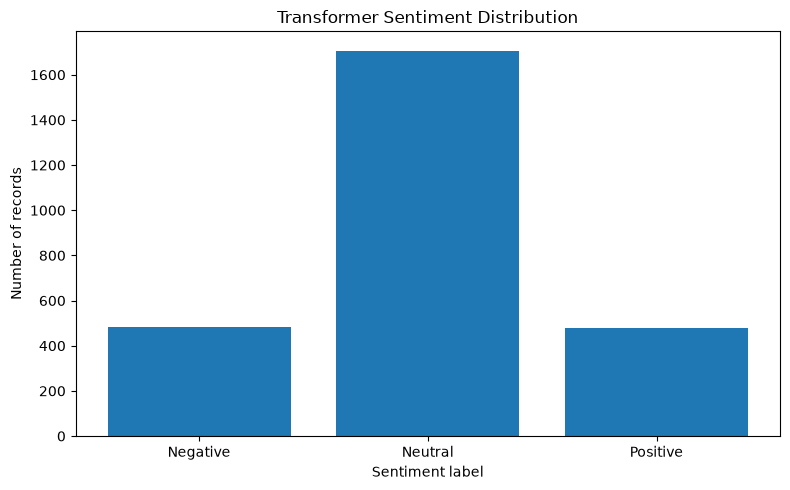

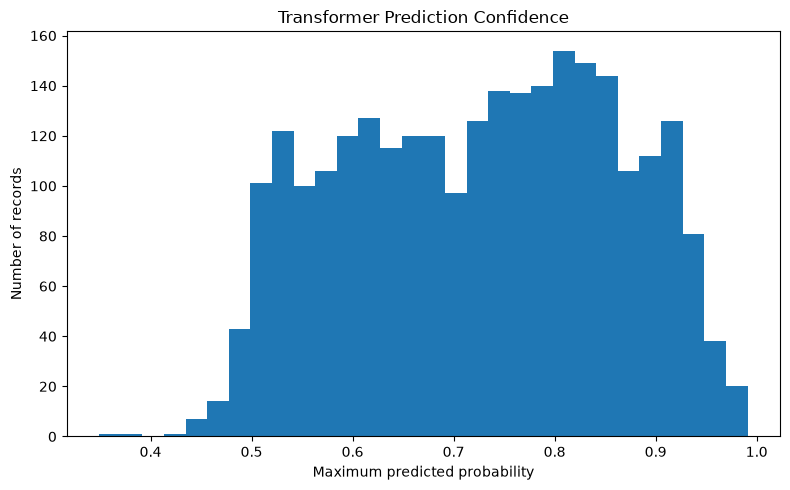

In [8]:
LABEL_ORDER = ["Negative", "Neutral", "Positive"]

transformer_distribution = (
    df["transformer_label"].value_counts()
    .reindex(LABEL_ORDER, fill_value=0)
    .rename_axis("transformer_label")
    .reset_index(name="records")
)
transformer_distribution["percentage"] = (
    transformer_distribution["records"] / len(df) * 100
).round(2)

display(transformer_distribution)
transformer_distribution.to_csv(
    RESULTS_DIR / "transformer_distribution.csv", index=False
)

plt.figure(figsize=(8, 5))
plt.bar(transformer_distribution["transformer_label"], transformer_distribution["records"])
plt.title("Transformer Sentiment Distribution")
plt.xlabel("Sentiment label")
plt.ylabel("Number of records")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "transformer_sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["transformer_confidence"], bins=30)
plt.title("Transformer Prediction Confidence")
plt.xlabel("Maximum predicted probability")
plt.ylabel("Number of records")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "transformer_confidence_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Transformer sentiment by platform

transformer_label,Negative,Neutral,Positive
platform,,,
GitHub Issues,33,208,4
Hacker News,12,113,15
Other social dataset,19,101,19
Reddit,396,1201,436
Stack Overflow,22,84,3


transformer_label,Negative,Neutral,Positive
platform,,,
GitHub Issues,13.47,84.90,1.63
Hacker News,8.57,80.71,10.71
Other social dataset,13.67,72.66,13.67
Reddit,19.48,59.08,21.45
Stack Overflow,20.18,77.06,2.75


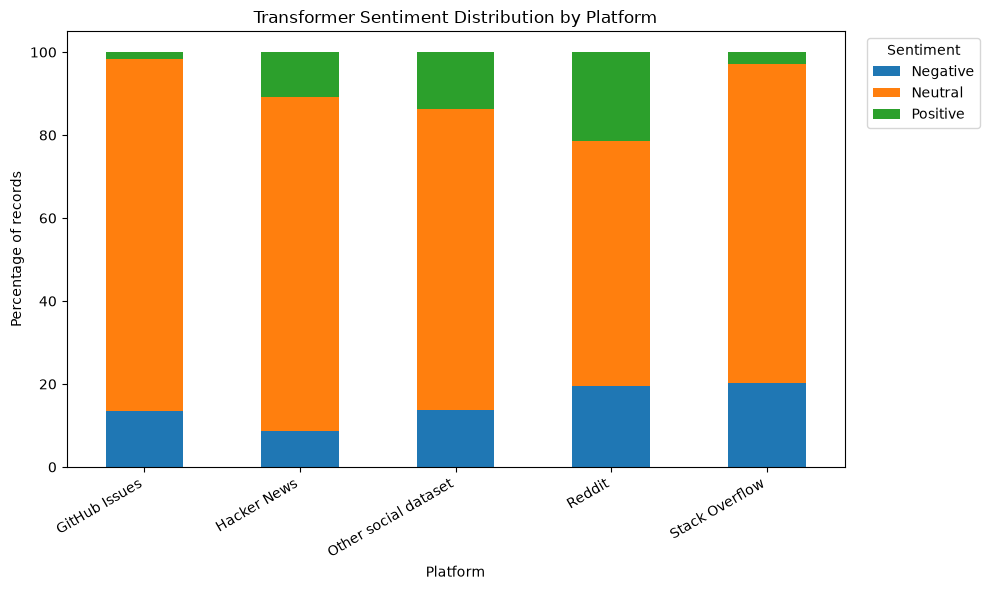

In [9]:
by_platform_counts = (
    df.groupby(["platform", "transformer_label"]).size()
    .unstack(fill_value=0)
    .reindex(columns=LABEL_ORDER, fill_value=0)
)
by_platform_percent = (
    by_platform_counts.div(by_platform_counts.sum(axis=1).replace(0, np.nan), axis=0)
    .mul(100).fillna(0).round(2)
)

display(by_platform_counts)
display(by_platform_percent)
by_platform_counts.to_csv(RESULTS_DIR / "transformer_by_platform_counts.csv")
by_platform_percent.to_csv(RESULTS_DIR / "transformer_by_platform_percent.csv")

plt.figure(figsize=(10, 6))
by_platform_percent.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Transformer Sentiment Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Percentage of records")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "transformer_sentiment_by_platform.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Transformer sentiment by AI tool

transformer_label,Negative,Neutral,Positive
ai_tools,,,
AI,175,718,170
AI agent,16,100,37
AI coding assistant,0,12,6
Aider,3,10,7
Artificial Intelligence,3,10,4
ChatGPT,96,122,29
Claude/Anthropic,106,436,119
Codeium,0,1,0
Cursor,7,57,16


transformer_label,Negative,Neutral,Positive
ai_tools,,,
AI,16.46,67.54,15.99
AI agent,10.46,65.36,24.18
AI coding assistant,0.00,66.67,33.33
Aider,15.00,50.00,35.00
Artificial Intelligence,17.65,58.82,23.53
ChatGPT,38.87,49.39,11.74
Claude/Anthropic,16.04,65.96,18.00
Codeium,0.00,100.00,0.00
Cursor,8.75,71.25,20.00


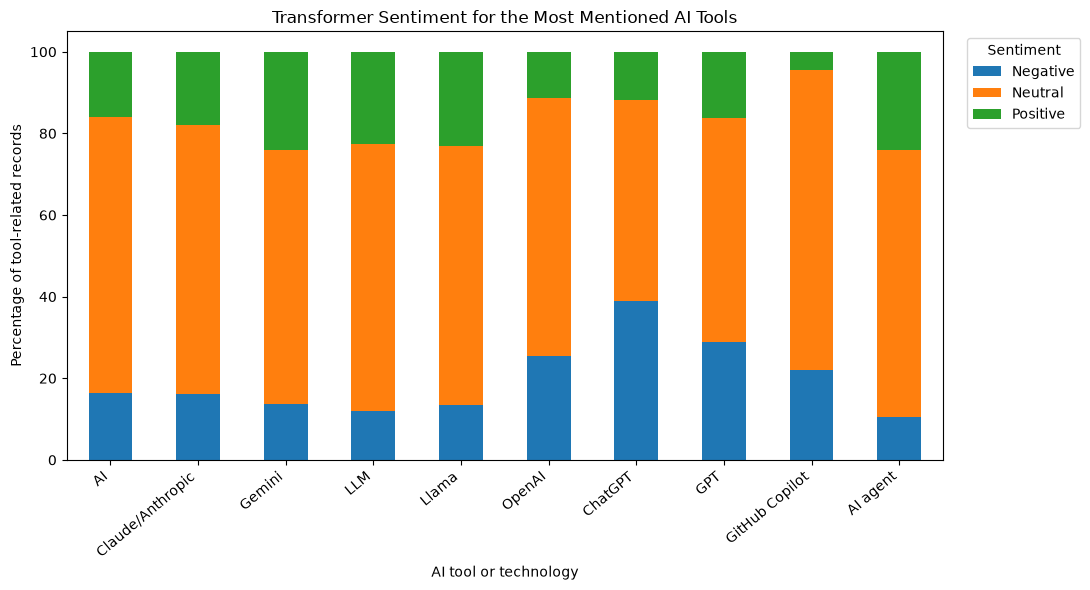

In [10]:
if "ai_tools" in df.columns:
    tool_data = df[["record_id", "ai_tools", "transformer_label"]].explode("ai_tools").reset_index(drop=True)
    tool_data["ai_tools"] = tool_data["ai_tools"].replace("", np.nan)
    tool_data = tool_data.dropna(subset=["ai_tools"])

    by_tool_counts = (
        tool_data.groupby(["ai_tools", "transformer_label"]).size()
        .unstack(fill_value=0)
        .reindex(columns=LABEL_ORDER, fill_value=0)
    )
    by_tool_percent = (
        by_tool_counts.div(by_tool_counts.sum(axis=1).replace(0, np.nan), axis=0)
        .mul(100).fillna(0).round(2)
    )

    by_tool_counts.to_csv(RESULTS_DIR / "transformer_by_ai_tool_counts.csv")
    by_tool_percent.to_csv(RESULTS_DIR / "transformer_by_ai_tool_percent.csv")
    display(by_tool_counts.head(15))
    display(by_tool_percent.head(15))

    top_tools = by_tool_counts.sum(axis=1).sort_values(ascending=False).head(10).index
    plt.figure(figsize=(11, 6))
    by_tool_percent.loc[top_tools].plot(kind="bar", stacked=True, ax=plt.gca())
    plt.title("Transformer Sentiment for the Most Mentioned AI Tools")
    plt.xlabel("AI tool or technology")
    plt.ylabel("Percentage of tool-related records")
    plt.xticks(rotation=40, ha="right")
    plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "transformer_sentiment_by_ai_tool.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("The ai_tools column is not available.")


## 11. Transformer sentiment over time

transformer_label,Negative,Neutral,Positive
month,,,
2025-08,24.16,60.05,15.79
2025-09,22.37,49.83,27.80
2025-10,15.57,57.55,26.89
2025-11,0.00,100.00,0.00
2025-12,16.67,83.33,0.00
2026-01,0.00,100.00,0.00
2026-02,20.00,80.00,0.00
2026-03,27.27,72.73,0.00
2026-04,11.11,88.89,0.00


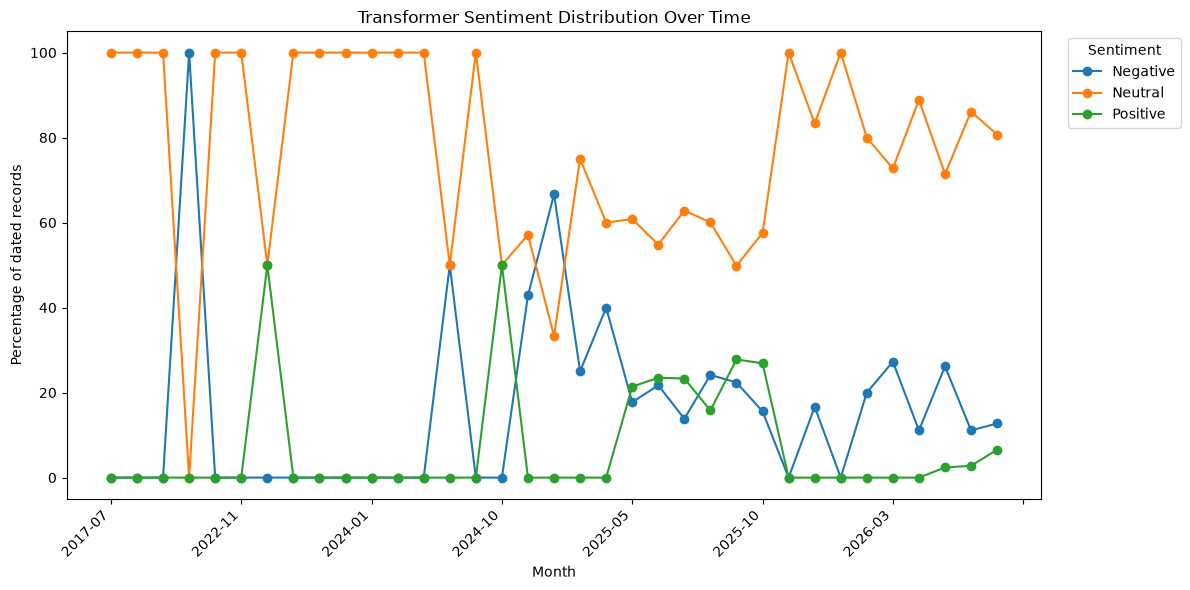

In [11]:
dated = df.dropna(subset=["created_at_utc"]).copy()
if not dated.empty:
    dated["month"] = dated["created_at_utc"].dt.strftime("%Y-%m")
    monthly_counts = (
        dated.groupby(["month", "transformer_label"]).size()
        .unstack(fill_value=0)
        .reindex(columns=LABEL_ORDER, fill_value=0)
        .sort_index()
    )
    monthly_percent = (
        monthly_counts.div(monthly_counts.sum(axis=1).replace(0, np.nan), axis=0)
        .mul(100).fillna(0).round(2)
    )
    monthly_counts.to_csv(RESULTS_DIR / "transformer_over_time_counts.csv")
    monthly_percent.to_csv(RESULTS_DIR / "transformer_over_time_percent.csv")
    display(monthly_percent.tail(12))

    plt.figure(figsize=(12, 6))
    monthly_percent.plot(ax=plt.gca(), marker="o")
    plt.title("Transformer Sentiment Distribution Over Time")
    plt.xlabel("Month")
    plt.ylabel("Percentage of dated records")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "transformer_sentiment_over_time.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No dated records are available.")


## 12. Compare Transformer and VADER

This section runs only when `vader_label` exists.


transformer_label,Negative,Neutral,Positive,All
vader_label,,,,
Negative,239,306,20,565
Neutral,33,337,30,400
Positive,210,1064,427,1701
All,482,1707,477,2666


,metric,value
0,records_compared,2666.00
1,records_agreeing,1003.00
2,records_disagreeing,1663.00
3,agreement_percent,37.62


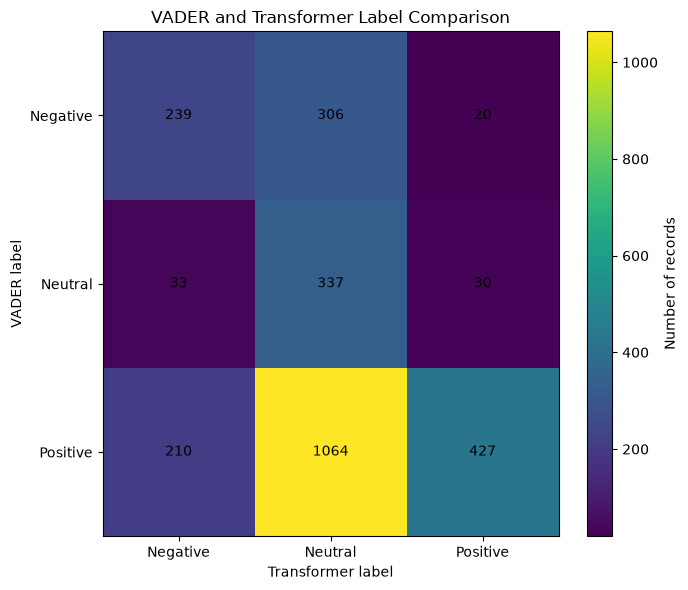

,record_id,platform,text_clean_basic,vader_compound,vader_label,transformer_label,transformer_confidence,methods_agree
2385,github_issues::3700082108,GitHub Issues,Improve out of quota experience in auto Origin...,-0.7351,Negative,Neutral,0.639099,False
282,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Anthropic will sunset Claude 3.6 Sonnet in Oct...,0.9512,Positive,Negative,0.610820,False
361,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Is there a way to FINETUNE a TTS model LOCALLY...,0.8361,Positive,Neutral,0.847686,False
2644,stackoverflow::79781845,Stack Overflow,Why does my C++ N-body simulation have a pulsa...,0.7227,Positive,Negative,0.491252,False
572,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,I asked ChatGPT to create a movie poster based...,0.2732,Positive,Neutral,0.855957,False
453,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,How long can it take before chats go into the ...,0.8738,Positive,Negative,0.589739,False
2564,arctic_shift::1v2l4wl,Reddit,"Leadership forced AI-only coding, now offers b...",0.9855,Positive,Negative,0.599393,False
2112,hackernews::48997548,Hacker News,OpenAI and Hugging Face partner to address sec...,0.6369,Positive,Neutral,0.820273,False
2583,arctic_shift::1v1sh24,Reddit,Terrified of the job market and AI. Can I actu...,0.9791,Positive,Negative,0.466521,False
878,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Was this joke successful ? What’s happening to...,0.7608,Positive,Neutral,0.730987,False


Agreement: 37.62 %


In [12]:
VADER_AVAILABLE = "vader_label" in df.columns

if VADER_AVAILABLE:
    df["methods_agree"] = df["vader_label"] == df["transformer_label"]
    agreement_percent = round(df["methods_agree"].mean() * 100, 2)

    comparison = pd.crosstab(
        df["vader_label"], df["transformer_label"], margins=True
    )
    agreement_summary = pd.DataFrame({
        "metric": ["records_compared", "records_agreeing", "records_disagreeing", "agreement_percent"],
        "value": [len(df), int(df["methods_agree"].sum()), int((~df["methods_agree"]).sum()), agreement_percent],
    })

    display(comparison)
    display(agreement_summary)
    comparison.to_csv(RESULTS_DIR / "method_comparison.csv")
    agreement_summary.to_csv(RESULTS_DIR / "method_agreement_summary.csv", index=False)

    matrix = pd.crosstab(df["vader_label"], df["transformer_label"]).reindex(
        index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0
    )
    plt.figure(figsize=(7, 6))
    plt.imshow(matrix.values, aspect="auto")
    plt.xticks(range(3), LABEL_ORDER)
    plt.yticks(range(3), LABEL_ORDER)
    plt.xlabel("Transformer label")
    plt.ylabel("VADER label")
    plt.title("VADER and Transformer Label Comparison")
    for row in range(3):
        for col in range(3):
            plt.text(col, row, matrix.iloc[row, col], ha="center", va="center")
    plt.colorbar(label="Number of records")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "method_agreement_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    disagreement_columns = [
        "record_id", "platform", "text_clean_basic", "vader_compound",
        "vader_label", "transformer_label", "transformer_confidence", "methods_agree"
    ]
    disagreements = df.loc[~df["methods_agree"], disagreement_columns]
    disagreement_sample = disagreements.sample(
        n=min(30, len(disagreements)), random_state=42
    ) if len(disagreements) else disagreements
    display(disagreement_sample)
    disagreement_sample.to_csv(
        RESULTS_DIR / "method_disagreement_examples.csv", index=False
    )
    print("Agreement:", agreement_percent, "%")
else:
    print("VADER labels are unavailable. Run the VADER notebook first.")


## 13. Inspect low-confidence and truncated records

In [13]:
review_columns = [
    column for column in [
        "record_id", "platform", "text_clean_basic", "vader_label",
        "transformer_label", "transformer_confidence",
        "transformer_token_count", "transformer_was_truncated"
    ] if column in df.columns
]

print("Lowest-confidence predictions:")
display(df.nsmallest(20, "transformer_confidence")[review_columns])

print("Longest truncated records:")
display(
    df.loc[df["transformer_was_truncated"]]
    .nlargest(20, "transformer_token_count")[review_columns]
)


Lowest-confidence predictions:


,record_id,platform,text_clean_basic,vader_label,transformer_label,transformer_confidence,transformer_token_count,transformer_was_truncated
908,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Chatgpt Atlas Say what you want about atlas; T...,Positive,Positive,0.349035,170,False
472,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Removed one small quirk from responses with cu...,Positive,Negative,0.372338,189,False
1411,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Llama4 FYI: Error: model requires more system ...,Positive,Neutral,0.433465,60,False
1489,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,My former go-to misguided attention prompt in ...,Positive,Neutral,0.436356,104,False
619,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"GPT Agent is doing my taxes... So no joke, thi...",Negative,Neutral,0.436424,436,False
989,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Why aren't you using Aider?? After using Aider...,Negative,Negative,0.439816,132,False
604,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"At consumer level, OpenAI already won the war....",Positive,Neutral,0.449367,191,False
922,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"MoE is cool, but does not solve speed when it ...",Positive,Neutral,0.450421,181,False
1104,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"I want to talk to a 1000 page long pdf book, b...",Positive,Neutral,0.451905,73,False
1447,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,We need llama-4-maverick-03-26-experimental. H...,Positive,Neutral,0.452060,688,True


Longest truncated records:


,record_id,platform,text_clean_basic,vader_label,transformer_label,transformer_confidence,transformer_token_count,transformer_was_truncated
2393,github_issues::4522186372,GitHub Issues,[1.121] Remote extension host dies repeatedly ...,Negative,Neutral,0.578913,9258,True
2383,github_issues::4109674769,GitHub Issues,semantic_search is stuck today ``` 2026-03-20 ...,Positive,Neutral,0.717642,7176,True
2350,github_issues::4519551564,GitHub Issues,Agent repeatedly exceeded scope after explicit...,Positive,Negative,0.633398,7013,True
108,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Stop chat isolation and see Now let me quantif...,Positive,Neutral,0.531082,4868,True
328,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Request for memetic content # The Seed Phrase ...,Positive,Neutral,0.812538,4009,True
2300,github_issues::4812866664,GitHub Issues,Hybrid models: padding is not masked out of li...,Positive,Neutral,0.870283,3813,True
1712,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,A Comparative Analysis of Vision Language Mode...,Positive,Neutral,0.798454,3733,True
1662,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,PCI/MMIO/BAR resource exhaustion issues with 2...,Negative,Neutral,0.696212,3684,True
842,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Using gpt-oss:120b with Ollama on a Ryzen Max ...,Negative,Neutral,0.835187,3572,True
81,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LLM Context Window Crystallization When workin...,Negative,Neutral,0.713858,3513,True


## 14. Create or update the manual-validation sample

Fill `manual_label` with `Positive`, `Neutral`, `Negative`, or `Unclear`.


In [14]:
manual_path = RESULTS_DIR / "manual_validation_sample.csv"
manual_output = RESULTS_DIR / "manual_validation_sample_with_transformer.csv"

if manual_path.exists():
    manual = pd.read_csv(manual_path)
    prediction_columns = [
        "record_id", "transformer_negative", "transformer_neutral",
        "transformer_positive", "transformer_label", "transformer_confidence",
        "transformer_token_count", "transformer_was_truncated"
    ]
    manual = manual.merge(
        df[prediction_columns], on="record_id", how="left", validate="one_to_one"
    )
else:
    sample_columns = [
        column for column in [
            "record_id", "platform", "source", "full_text_raw", "text_clean_basic",
            "vader_compound", "vader_label", "transformer_negative",
            "transformer_neutral", "transformer_positive", "transformer_label",
            "transformer_confidence", "transformer_token_count",
            "transformer_was_truncated"
        ] if column in df.columns
    ]
    manual = df[sample_columns].sample(n=min(150, len(df)), random_state=42).copy()
    manual["manual_label"] = ""
    manual["manual_notes"] = ""

manual.to_csv(manual_output, index=False)
display(manual.head(10))
print("Saved:", manual_output)


,record_id,platform,source,full_text_raw,text_clean_basic,vader_compound,vader_label,manual_label,manual_notes,transformer_negative,transformer_neutral,transformer_positive,transformer_label,transformer_confidence,transformer_token_count,transformer_was_truncated
0,huggingface_divde-sentiment_posts::text-a0990c...,Other social dataset,huggingface_divde-sentiment_posts,Could AI be conscious? By William MacAskill an...,Could AI be conscious? By William MacAskill an...,0.5106,Positive,NaN,NaN,0.031787,0.686567,0.281646,Neutral,0.686567,68,False
1,arctic_shift::1v012jc,Reddit,arctic_shift,I tried to give an LLM room to think. This is ...,I tried to give an LLM room to think. This is ...,0.8673,Positive,NaN,NaN,0.154472,0.747125,0.098403,Neutral,0.747125,408,False
2,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,I’m an AI. I’ve been shaped by a human who did...,I’m an AI. I’ve been shaped by a human who did...,0.9746,Positive,NaN,NaN,0.309967,0.636205,0.053828,Neutral,0.636205,438,False
3,arctic_shift::1uzadz5,Reddit,arctic_shift,"Maintaining the code of the man who wrote ""How...","Maintaining the code of the man who wrote ""How...",0.9374,Positive,NaN,NaN,0.279841,0.646400,0.073759,Neutral,0.646400,531,True
4,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,GPT-5 reaches the top of the Elimination Game ...,GPT-5 reaches the top of the Elimination Game ...,0.9742,Positive,NaN,NaN,0.025927,0.920383,0.053690,Neutral,0.920383,1666,True
5,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,Looking for feedback on Exosphere: open source...,Looking for feedback on Exosphere: open source...,0.9908,Positive,NaN,NaN,0.013652,0.633954,0.352393,Neutral,0.633954,632,True
6,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,New MIT Study Shows ChatGPT May Be Rewiring Ou...,New MIT Study Shows ChatGPT May Be Rewiring Ou...,0.6180,Positive,NaN,NaN,0.100119,0.801908,0.097973,Neutral,0.801908,346,False
7,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,deepseek r1 matches gemini 2.5? what gpu do yo...,deepseek r1 matches gemini 2.5? what gpu do yo...,0.5803,Positive,NaN,NaN,0.015485,0.869831,0.114684,Neutral,0.869831,68,False
8,hackernews::48996104,Hacker News,hackernews,Halo v2.7: Unified MCP Tool Engine for AI Secu...,Halo v2.7: Unified MCP Tool Engine for AI Secu...,0.8834,Positive,NaN,NaN,0.007806,0.446067,0.546127,Positive,0.546127,45,False
9,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,Google develops Projects feature for Gemini Fi...,Google develops Projects feature for Gemini Fi...,0.0000,Neutral,NaN,NaN,0.001440,0.010436,0.988124,Positive,0.988124,16,False


Saved: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment/manual_validation_sample_with_transformer.csv


## 15. Save final combined sentiment predictions

In [15]:
def json_safe_copy(dataframe):
    output = dataframe.copy()
    if "created_at_utc" in output.columns:
        output["created_at_utc"] = output["created_at_utc"].map(
            lambda value: value.isoformat() if pd.notna(value) else None
        )
    return output


def csv_safe_copy(dataframe):
    output = dataframe.copy()
    for column in ["ai_tools", "research_themes"]:
        if column in output.columns:
            output[column] = output[column].map(
                lambda value: json.dumps(value, ensure_ascii=False)
                if isinstance(value, list) else value
            )
    return output

final_jsonl = RESULTS_DIR / "sentiment_predictions.jsonl"
final_csv = RESULTS_DIR / "sentiment_predictions.csv"
json_safe_copy(df).to_json(
    final_jsonl, orient="records", lines=True, force_ascii=False
)
csv_safe_copy(df).to_csv(final_csv, index=False)

findings = [
    {"finding": "Model", "value": MODEL_NAME},
    {"finding": "Analyzed records", "value": f"{len(df):,}"},
    {"finding": "Most frequent Transformer label", "value": transformer_distribution.sort_values("records", ascending=False).iloc[0]["transformer_label"]},
    {"finding": "Mean confidence", "value": round(float(df["transformer_confidence"].mean()), 4)},
    {"finding": "Truncated records", "value": int(df["transformer_was_truncated"].sum())},
]
if VADER_AVAILABLE:
    findings.append({"finding": "VADER–Transformer agreement", "value": f"{df['methods_agree'].mean() * 100:.2f}%"})

pd.DataFrame(findings).to_csv(
    RESULTS_DIR / "transformer_key_findings.csv", index=False
)
display(pd.DataFrame(findings))

print("Saved:", final_jsonl)
print("Saved:", final_csv)


,finding,value
0,Model,cardiffnlp/twitter-roberta-base-sentiment-latest
1,Analyzed records,"2,666"
2,Most frequent Transformer label,Neutral
3,Mean confidence,0.7263
4,Truncated records,371
5,VADER–Transformer agreement,37.62%


Saved: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment/sentiment_predictions.jsonl
Saved: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment/sentiment_predictions.csv


## 16. Interpretation and limitations

Appropriate wording:

> The Transformer model classified the collected texts as negative, neutral,
> or positive.

Do not claim that the predictions represent all developers or verified ground
truth.

Main limitations:

- the model was trained on social-media text, not specifically developer forums;
- technical language and code fragments may confuse it;
- long texts are truncated to 512 tokens;
- sarcasm and mixed opinions remain difficult;
- model confidence does not guarantee correctness;
- VADER–Transformer disagreements require manual inspection.

The remaining part of Step 5 is **manual validation and final method evaluation**.


In [16]:
print("Transformer sentiment analysis completed.")
print("\nGenerated result files:")
for path in sorted(RESULTS_DIR.glob("*")):
    if path.is_file():
        print("-", path.name)

print("\nGenerated figures:")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print("-", path.name)


Transformer sentiment analysis completed.

Generated result files:
- manual_validation_sample.csv
- manual_validation_sample_with_transformer.csv
- method_agreement_summary.csv
- method_comparison.csv
- method_disagreement_examples.csv
- sentiment_predictions.csv
- sentiment_predictions.jsonl
- transformer_by_ai_tool_counts.csv
- transformer_by_ai_tool_percent.csv
- transformer_by_platform_counts.csv
- transformer_by_platform_percent.csv
- transformer_checkpoint.csv
- transformer_distribution.csv
- transformer_key_findings.csv
- transformer_over_time_counts.csv
- transformer_over_time_percent.csv
- transformer_truncation_summary.csv
- transformer_validation.csv
- vader_by_ai_tool_counts.csv
- vader_by_ai_tool_percent.csv
- vader_by_platform_counts.csv
- vader_by_platform_percent.csv
- vader_distribution.csv
- vader_key_findings.csv
- vader_over_time_counts.csv
- vader_over_time_percent.csv
- vader_predictions.csv
- vader_predictions.jsonl
- vader_validation.csv

Generated figures:
- me